## Paso 1: Limpieza del Dataset IBM HR
## Cargamos el dataset original y aplicamos limpieza básica: eliminación de constantes, IDs y conversión del target

In [1]:
# --- Importación de librerias y configuración ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Configuración de los gráficos ---
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

# --- Carga IBM HR (dataset principal) ---
ibm = pd.read_csv('../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f'Shape original: {ibm.shape}')
print(f'Columnas: {ibm.columns.tolist()}')

Shape original: (1470, 35)
Columnas: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [2]:
# --- Eliminación de variables sin valor para el modelo

# Primero verificamos cuáles son las variables constantes (las que tienen un solo valor en toda la columna)
constantes = ibm.columns[ibm.nunique() == 1].tolist()
print(f'Variables constantes encontradas: {constantes}')

Variables constantes encontradas: ['EmployeeCount', 'Over18', 'StandardHours']


In [3]:
# Hacemos una doble verificación de que sus valores son unicos antes de eliminarlos
for col in constantes:
    print(f'  {col}: {ibm[col].unique()}')

  EmployeeCount: [1]
  Over18: <StringArray>
['Y']
Length: 1, dtype: str
  StandardHours: [80]


In [5]:
# Eliminamos las constantes y EmployeeNumber que es un ID
cols_eliminar = constantes + ['EmployeeNumber']
ibm_clean = ibm.drop(columns=cols_eliminar)

print(f'\nColumnas eliminadas: {cols_eliminar}')
print(f'Shape despues de limpieza: {ibm_clean.shape}')


Columnas eliminadas: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
Shape despues de limpieza: (1470, 31)


Nota: En la limpieza se validó lo visualizado en la carga de la data, de cuáles eran los valores con constantes unicos: EmployeeCount, Over18 y Creamos ibm_clean como copia limpia en vez de modificar ibm con inplace=True, para no modificar directamente el dataset original por si más adelante cometemos algun error.

In [6]:
# --- Convertir el target (attritin) a númerico ---

# Visualización de la distribución antes de convertir
print('Distribución original:')
print(ibm_clean['Attrition'].value_counts())
print(ibm_clean['Attrition'].value_counts(normalize=True).round(3))

Distribución original:
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     0.839
Yes    0.161
Name: proportion, dtype: float64


In [7]:
# Conversión a Binario: Yes/No a 1/0
ibm_clean['Attrition'] = ibm_clean['Attrition'].map({'Yes': 1, 'No': 0})

print(f'\nDespués de conversión:')
print(ibm_clean['Attrition'].value_counts())
print(ibm_clean['Attrition'].value_counts(normalize=True).round(3))


Después de conversión:
Attrition
0    1233
1     237
Name: count, dtype: int64
Attrition
0    0.839
1    0.161
Name: proportion, dtype: float64


Notas: Nos pudimos dar cuenta que al volver a ejecutar esta parte por segunda vez (el .map({'Yes': 1, 'No': 0})), nos dió error y salió en blanco la parte de series porque ya no tenia los valores de yes y no.
Tuvimos que volver a ejecutar todo desde el dataset original, para corregir el problema. 

Observación: El target esta desbalanceado (84% No vs 16% Yes). Esto va a afectar el entrenamiento de los modelos. Habrá que aplicar técnicas como class_weight='balanced' para compensar.

In [8]:
# --- Verificamos nulos y guardado del dataset ---

nulos = ibm_clean.isnull().sum()
print(f'Total de nulos: {nulos.sum()}')

# Si hay nulos, mostrar cuales columnas
if nulos.sum() > 0:
    print('\nColumnas con nulos:')
    print(nulos[nulos > 0])
else:
    print('No se encontraron valores nulos en el dataset.')

# Guardar dataset limpio
ibm_clean.to_csv('../data/processed/ibm_hr_clean.csv', index=False)
print(f'\nDataset limpio guardado en data/processed/ibm_hr_clean.csv')
print(f'Shape final: {ibm_clean.shape}')

Total de nulos: 0
No se encontraron valores nulos en el dataset.

Dataset limpio guardado en data/processed/ibm_hr_clean.csv
Shape final: (1470, 31)


Nota: El IBM HR no tiene valores nulos, al parecer por ser uno sintetico. En el Extended que usaremos para validación si tiene.

In [9]:
# --- Resumen de la limpieza realizada ---

print('=== RESUMEN DE LIMPIEZA ===')
print(f'Filas: {ibm_clean.shape[0]} (sin cambios)')
print(f'Columnas originales: {ibm.shape[1]}')
print(f'Columnas despues de limpieza: {ibm_clean.shape[1]}')
print(f'Columnas eliminadas ({ibm.shape[1] - ibm_clean.shape[1]}): {cols_eliminar}')
print(f'Valores nulos: 0')
print(f'Target convertido: Yes/No a 1/0')
print(f'Desbalanceo: {ibm_clean["Attrition"].mean():.1%} attrition')

=== RESUMEN DE LIMPIEZA ===
Filas: 1470 (sin cambios)
Columnas originales: 35
Columnas despues de limpieza: 31
Columnas eliminadas (4): ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
Valores nulos: 0
Target convertido: Yes/No a 1/0
Desbalanceo: 16.1% attrition


## Paso 2: Análisis Univariado
## Distribución de variables numéricas clave, separadas por Attrition (1=se fue, 0=se quedo).

In [10]:
# --- Creación de carpeta para las gráficas ---
os.makedirs('../reports/figures', exist_ok=True)
print('Carpeta reports/figures/ lista')

Carpeta reports/figures/ lista


In [11]:
print(ibm_clean[['MonthlyIncome','MonthlyRate']].corr())

               MonthlyIncome  MonthlyRate
MonthlyIncome       1.000000     0.034814
MonthlyRate         0.034814     1.000000


Validación de variable: MonthlyIncome vs MonthlyRate: Antes de definir las variables que utilizariamos, verificamos si MonthlyRate aportaba información diferente a MonthlyIncome.

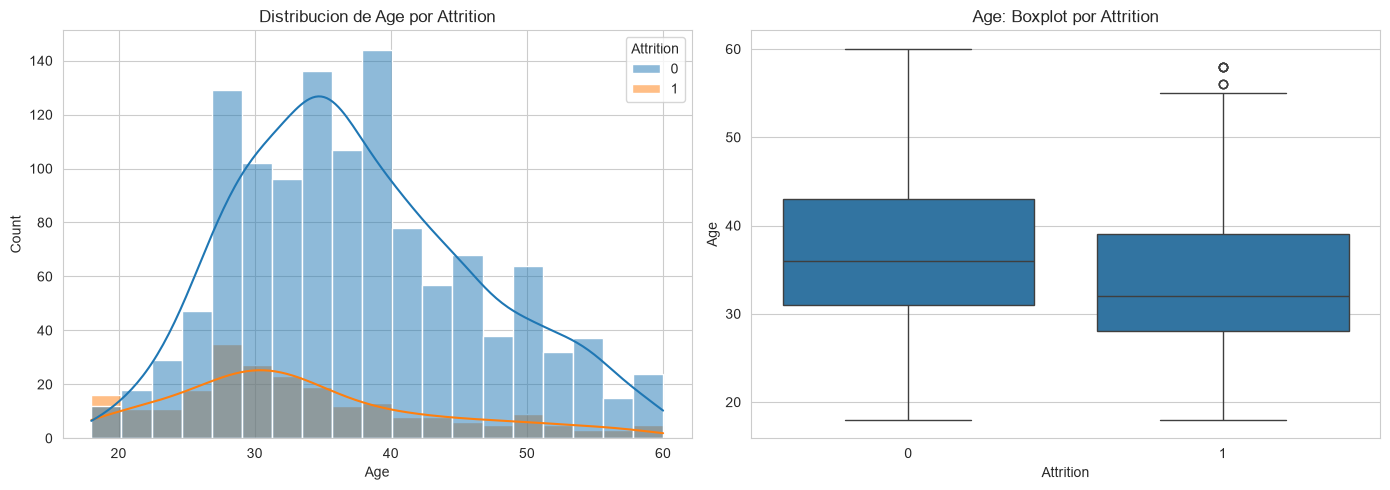

Guardada: dist_age.png



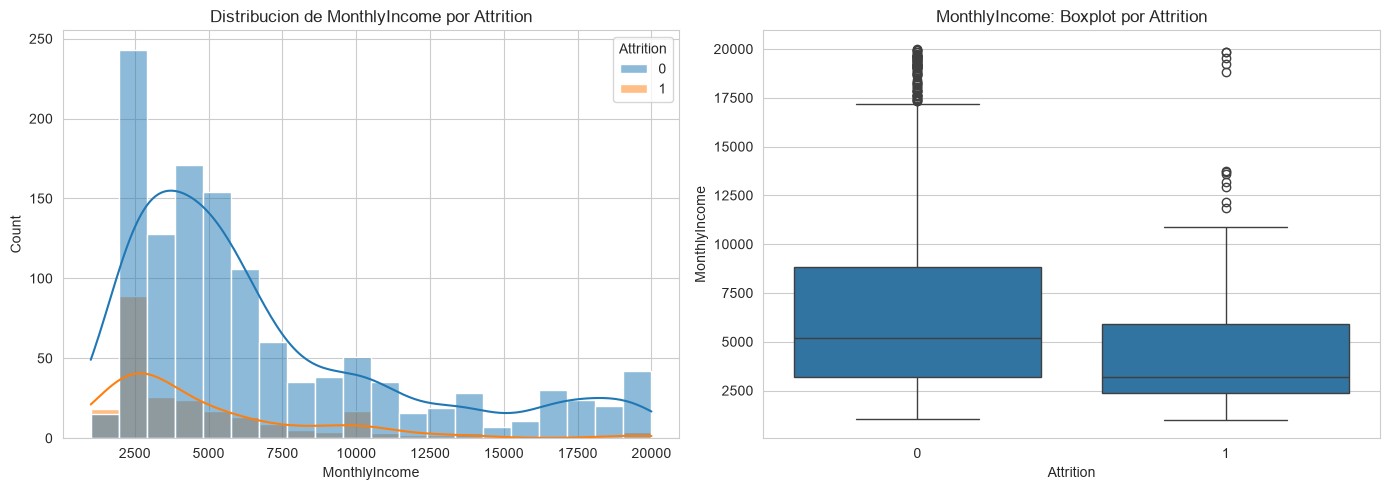

Guardada: dist_monthlyincome.png



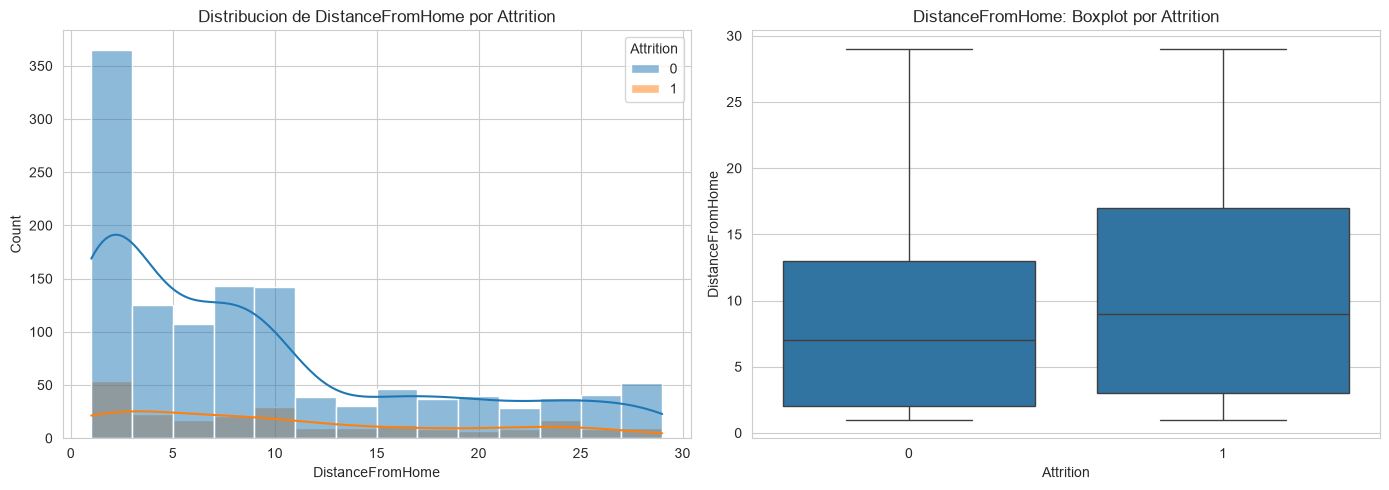

Guardada: dist_distancefromhome.png



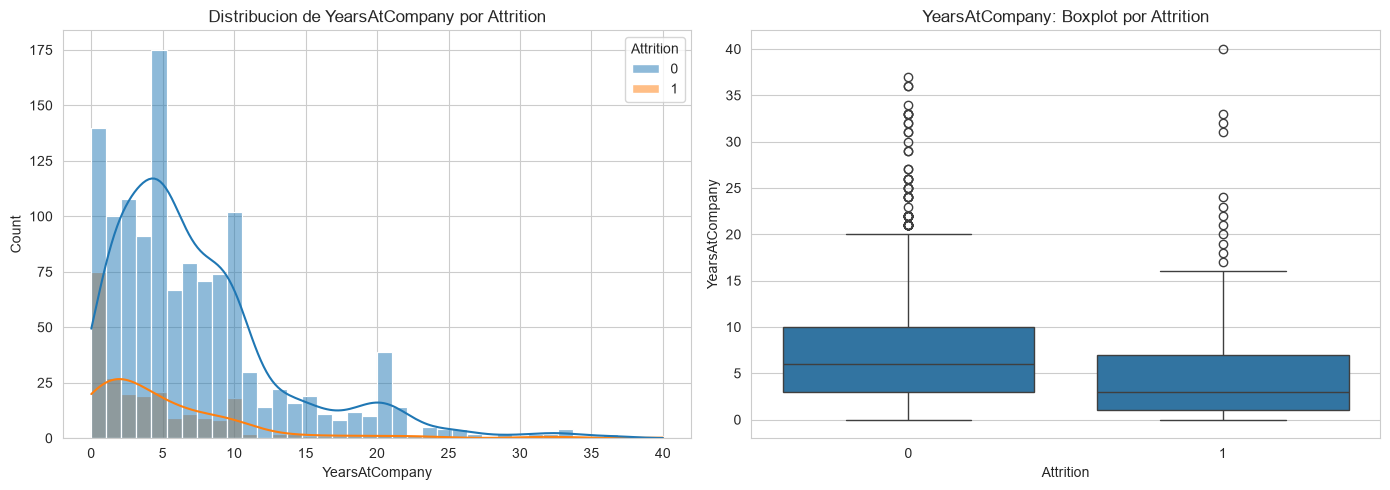

Guardada: dist_yearsatcompany.png



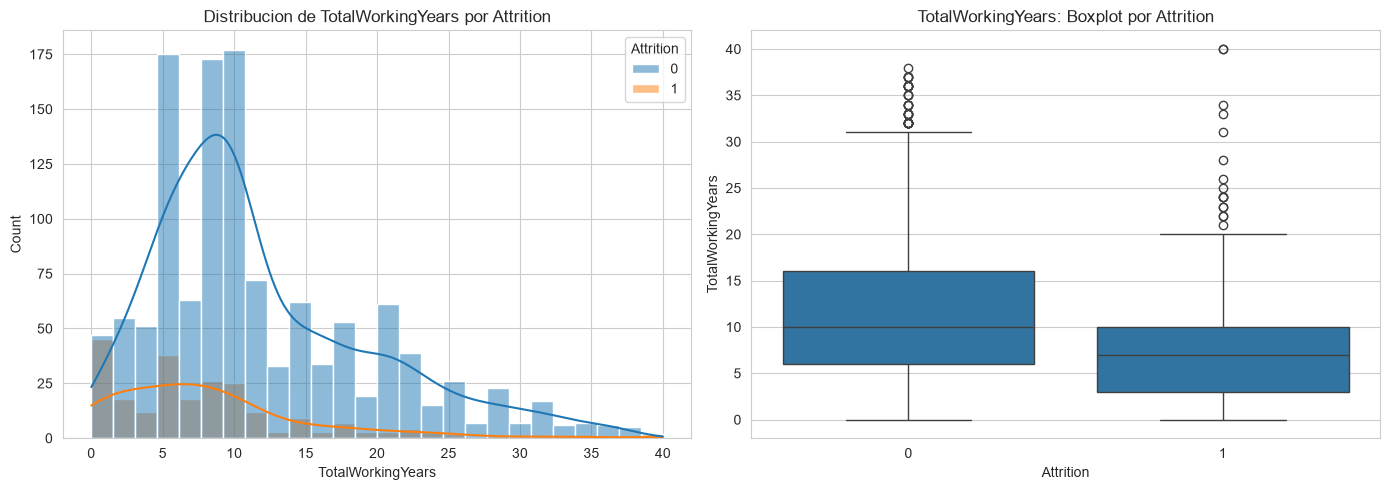

Guardada: dist_totalworkingyears.png



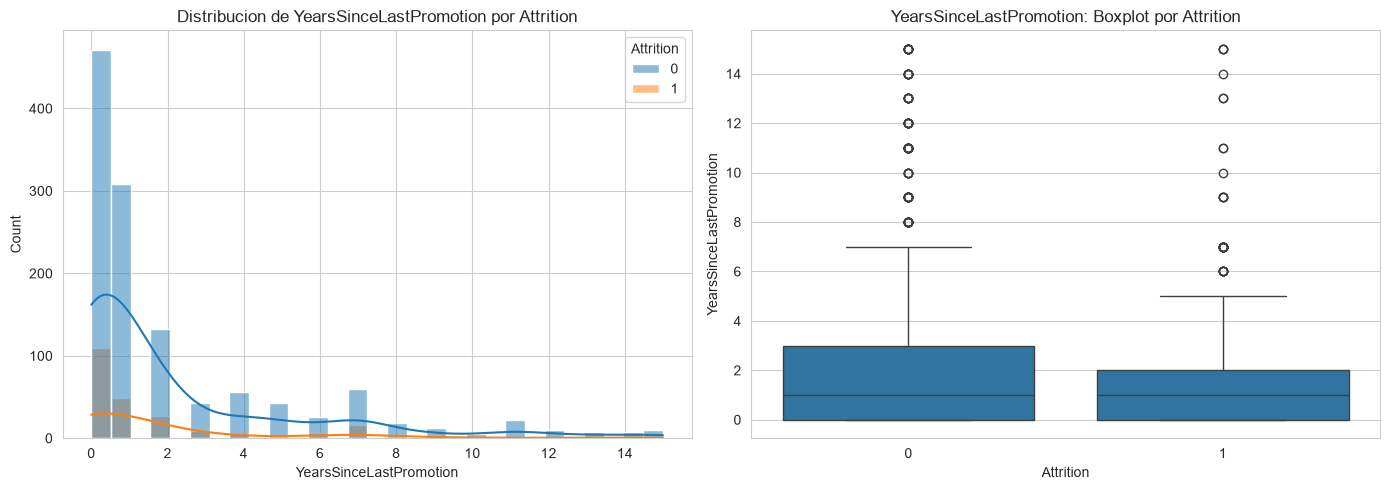

Guardada: dist_yearssincelastpromotion.png



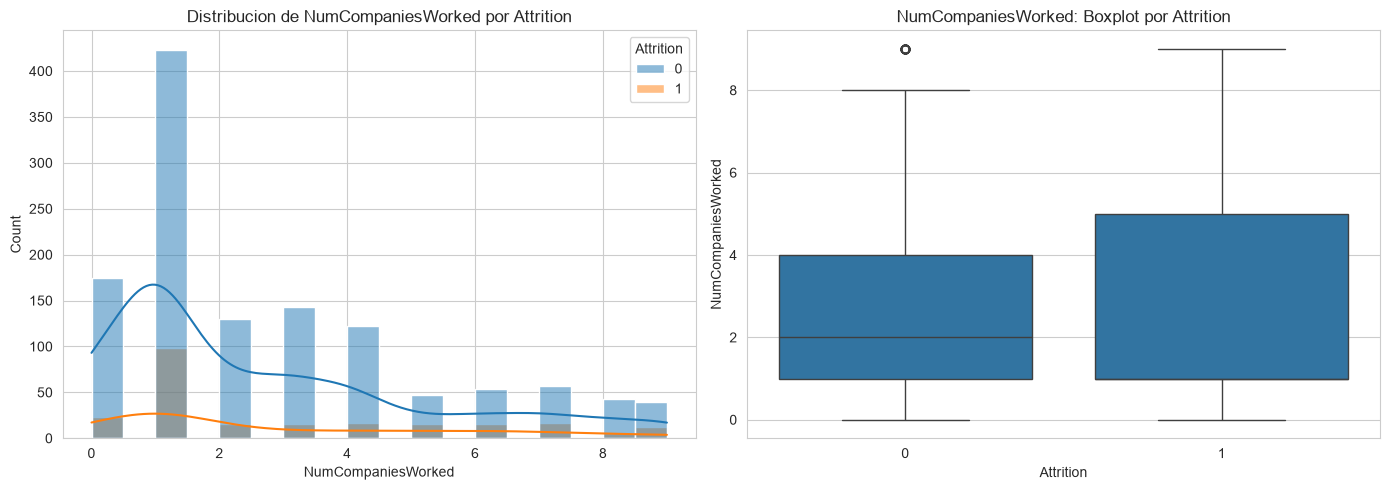

Guardada: dist_numcompaniesworked.png



In [12]:
# --- Histogramas por Attrition ---

vars_numericas = ['Age', 'MonthlyIncome', 'DistanceFromHome',
                  'YearsAtCompany', 'TotalWorkingYears',
                  'YearsSinceLastPromotion', 'NumCompaniesWorked']

for var in vars_numericas:
 ## fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histograma
    sns.histplot(data=ibm_clean, x=var, hue='Attrition',
                 kde=True, ax=axes[0])
    axes[0].set_title(f'Distribucion de {var} por Attrition')
    
    # Boxplot
    sns.boxplot(data=ibm_clean, x='Attrition', y=var, ax=axes[1])
    axes[1].set_title(f'{var}: Boxplot por Attrition')
    
    plt.tight_layout()
    plt.savefig(f'../reports/figures/dist_{var.lower()}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Guardada: dist_{var.lower()}.png')
    print()

Nota: Se probaron dos tamaños y se eligió (14, 5) porque permite visualizar mejor la diferencia en las variables y analizar mejor.

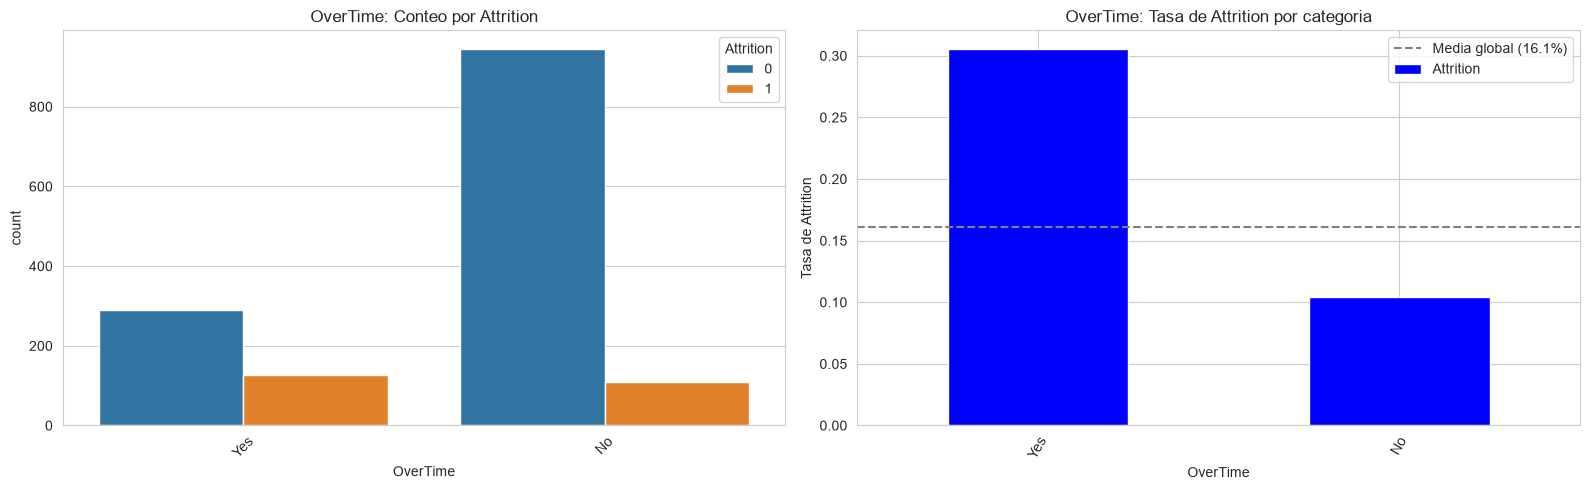

Guardada: cat_overtime.png



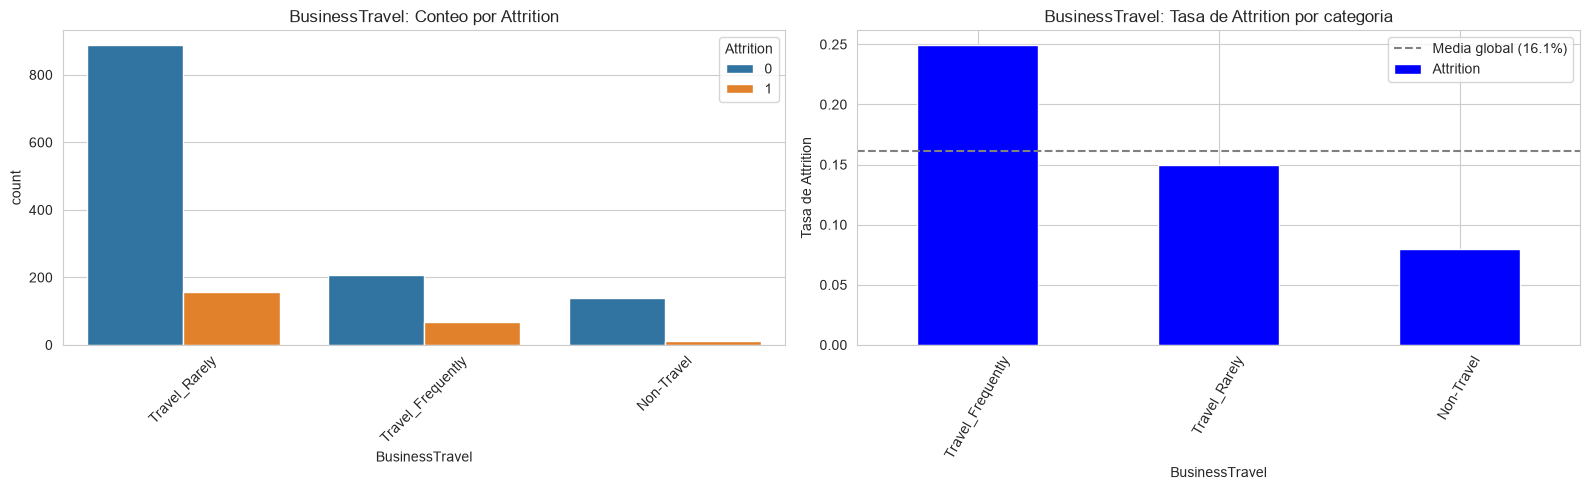

Guardada: cat_businesstravel.png



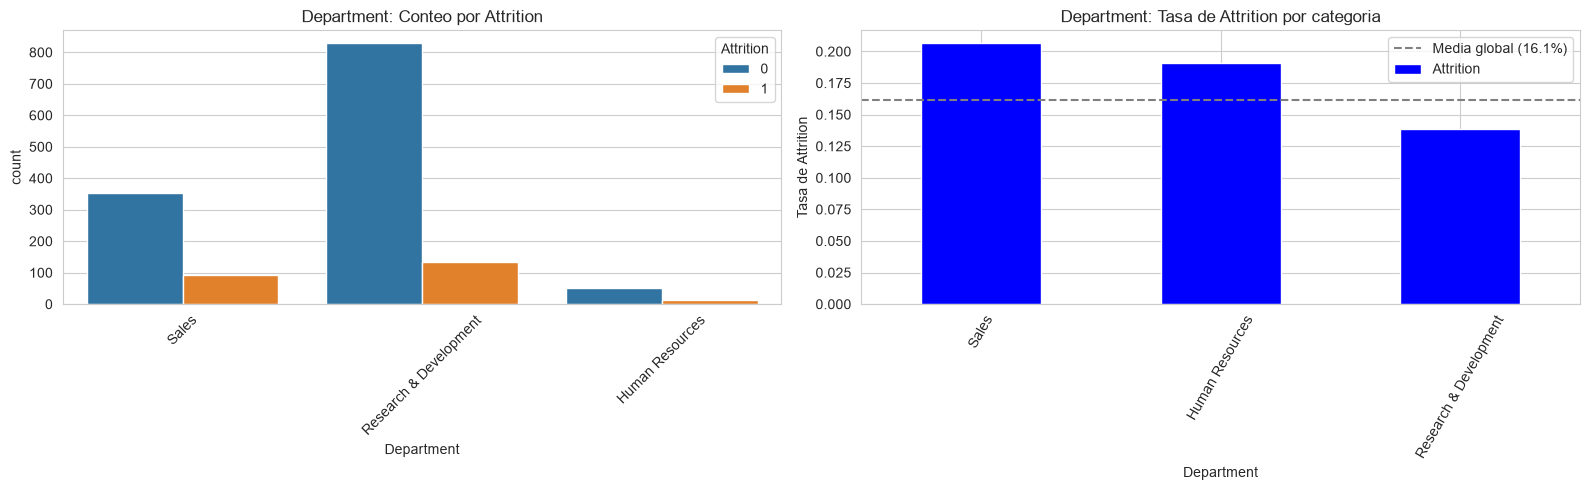

Guardada: cat_department.png



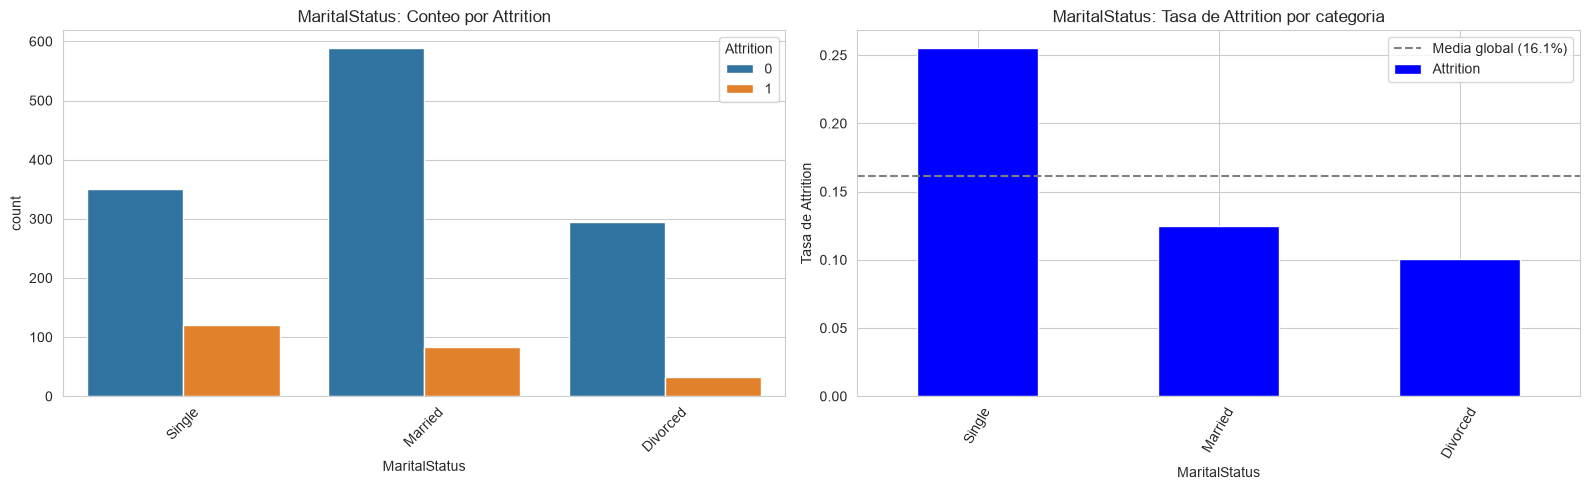

Guardada: cat_maritalstatus.png



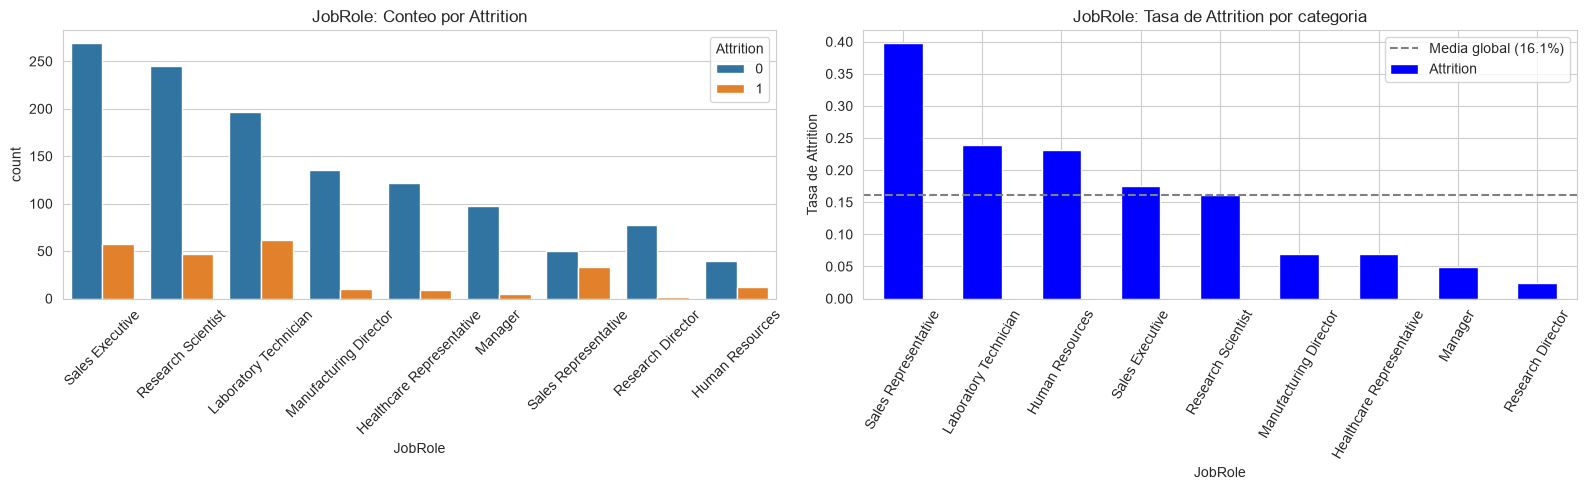

Guardada: cat_jobrole.png



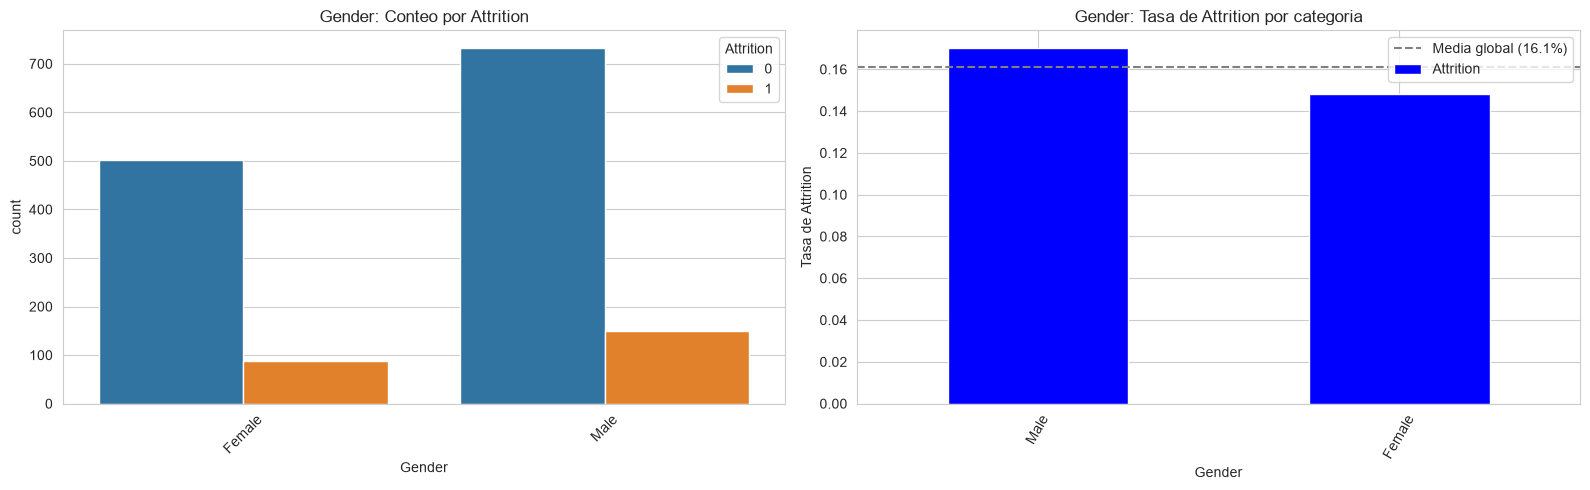

Guardada: cat_gender.png



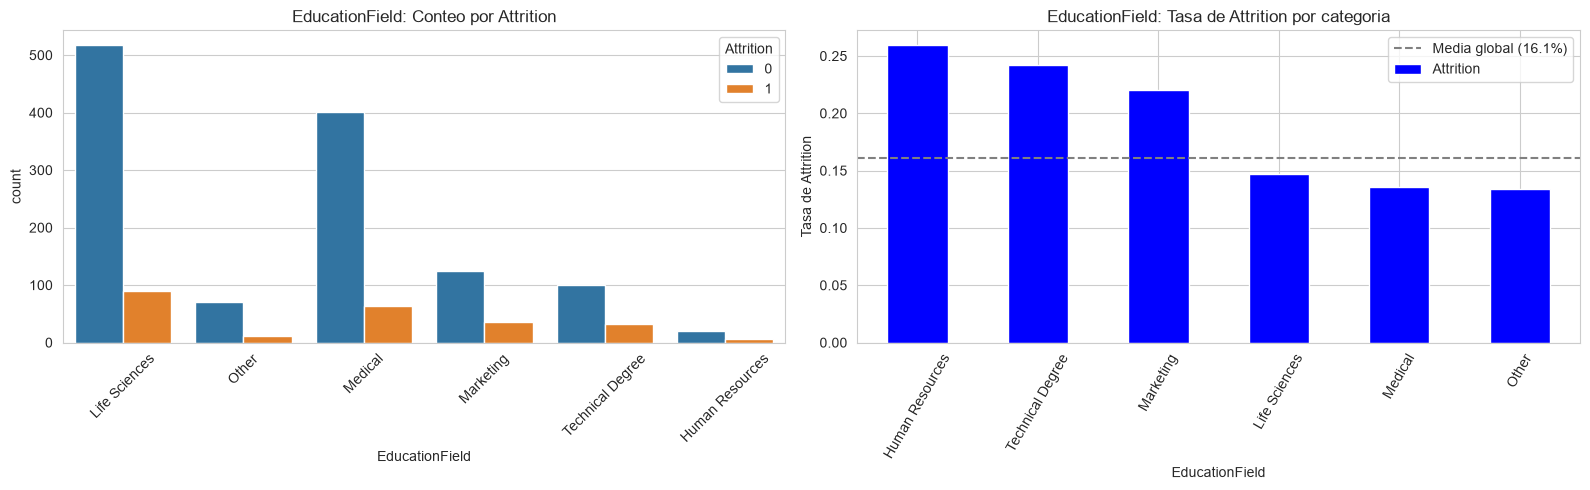

Guardada: cat_educationfield.png



In [13]:
# --- Variables categóricas vs Attrition ---

vars_categoricas = ['OverTime', 'BusinessTravel', 'Department',
                    'MaritalStatus', 'JobRole', 'Gender',
                    'EducationField']

for var in vars_categoricas:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Conteo simple
    sns.countplot(data=ibm_clean, x=var, hue='Attrition', ax=axes[0])
    axes[0].set_title(f'{var}: Conteo por Attrition')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Tasa de attrition por categoria
    tasa = ibm_clean.groupby(var)['Attrition'].mean().sort_values(ascending=False)
    tasa.plot(kind='bar', ax=axes[1], color='blue')
    axes[1].set_title(f'{var}: Tasa de Attrition por categoria')
    axes[1].set_ylabel('Tasa de Attrition')
 ## axes[1].tick_params(axis='x', rotation=45)
    axes[1].tick_params(axis='x', rotation=60)
    # Linea de referencia con la media global
    axes[1].axhline(y=ibm_clean['Attrition'].mean(), color='gray',
                    linestyle='--', label=f'Media global ({ibm_clean["Attrition"].mean():.1%})')
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(f'../reports/figures/cat_{var.lower()}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Guardada: cat_{var.lower()}.png')
    print()

Hallazgo: A simple vista podemos ver que hay dos variables a las que debemos prestar especial atención de momento, los empleados que trabajan horas extras y los que son representantes de ventas.
Son los que tienen una tasa de attrition mayor. Es algo que va de la mano con la teoría del Burnout.

## Variables de satisfacción
## Estas variables usan escalas ordinales (1-4). Analizamos la tasa de attrition por nivel de satisfacción.

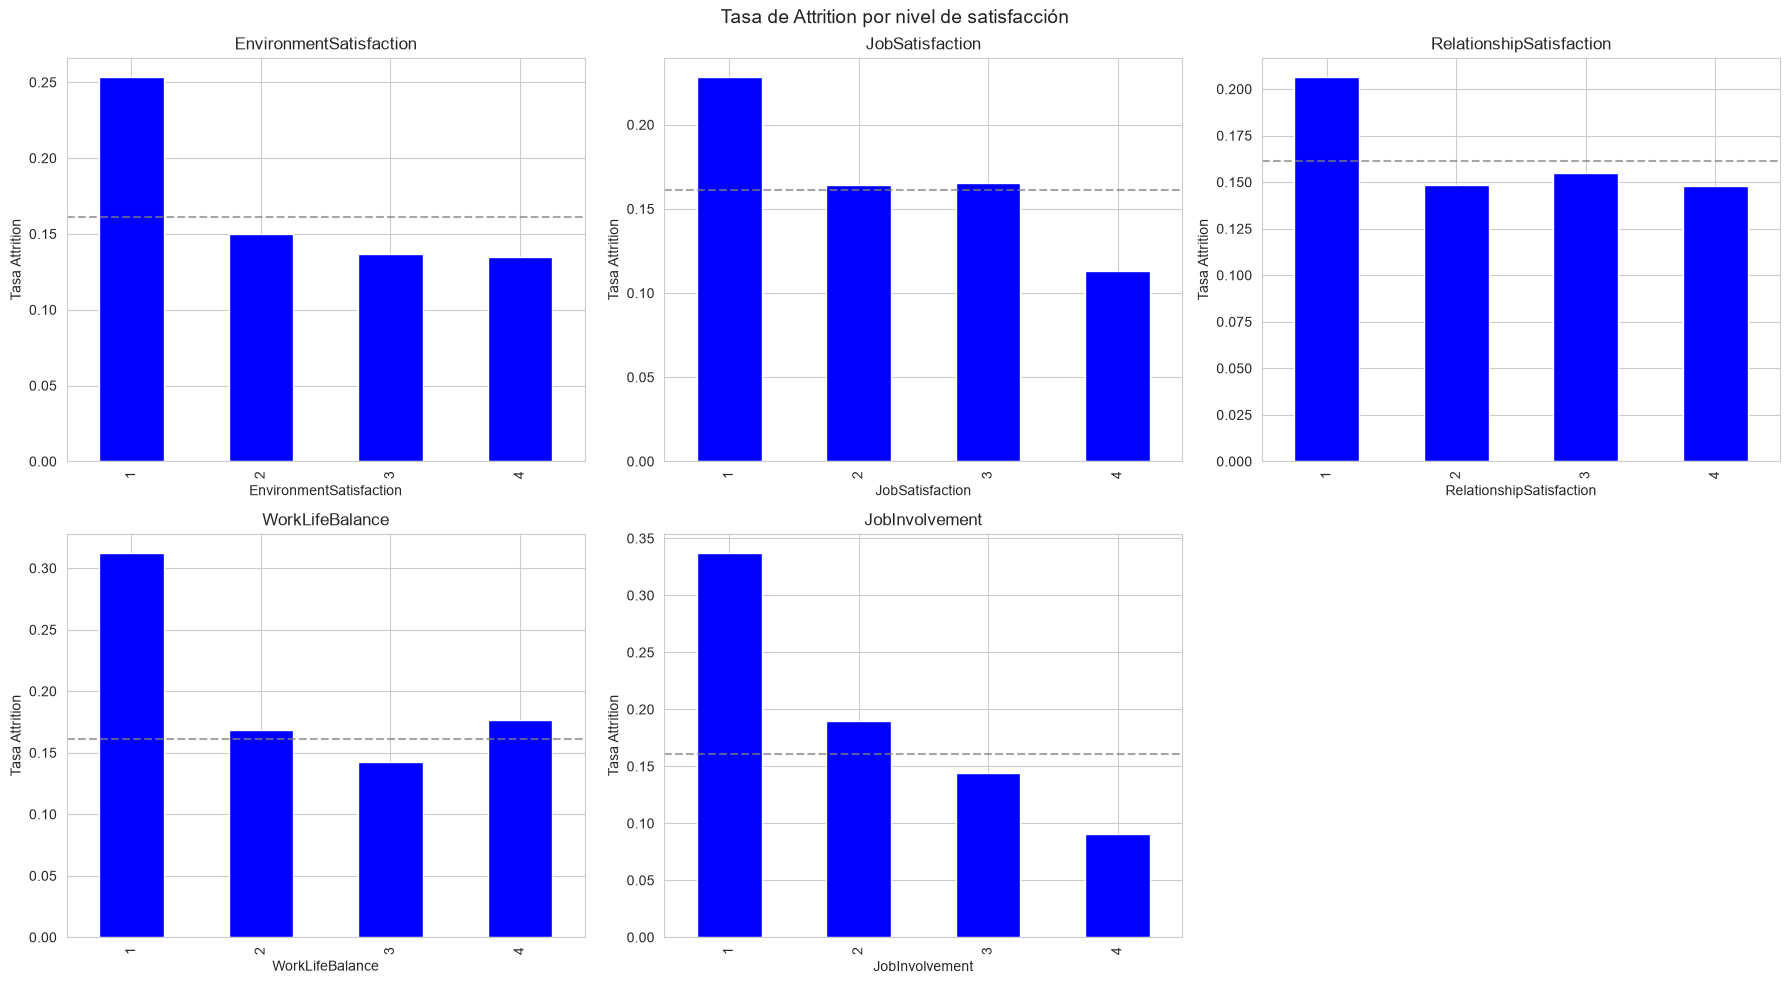

In [14]:
# --- Variables ordinales de satisfacción ---

vars_satisfaccion = ['EnvironmentSatisfaction', 'JobSatisfaction',
                     'RelationshipSatisfaction', 'WorkLifeBalance',
                     'JobInvolvement']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, var in enumerate(vars_satisfaccion):
    tasa = ibm_clean.groupby(var)['Attrition'].mean()
    tasa.plot(kind='bar', ax=axes[i], color='blue')
    axes[i].set_title(f'{var}')
    axes[i].set_ylabel('Tasa Attrition')
    axes[i].axhline(y=ibm_clean['Attrition'].mean(), color='gray',
                    linestyle='--', alpha=0.7)

# Ocultar el subplot sobrante al solo tener 5 variables
axes[-1].set_visible(False)

plt.suptitle('Tasa de Attrition por nivel de satisfacción', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/satisfaccion_vs_attrition.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# --- Detección de outliers ---

vars_outliers = ['MonthlyIncome', 'YearsAtCompany', 'DistanceFromHome',
                 'TotalWorkingYears', 'NumCompaniesWorked',
                 'YearsInCurrentRole', 'YearsWithCurrManager',
                 'YearsSinceLastPromotion']

print('=== DETECCIÓN DE OUTLIERS (método IQR) ===')
for var in vars_outliers:
    Q1 = ibm_clean[var].quantile(0.25)
    Q3 = ibm_clean[var].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ibm_clean[(ibm_clean[var] < lower) | (ibm_clean[var] > upper)]
    print(f'{var}: {len(outliers)} outliers ({len(outliers)/len(ibm_clean):.1%})')
    print(f'  Rango normal: [{lower:.0f}, {upper:.0f}]')
    print(f'  Rango real: [{ibm_clean[var].min()}, {ibm_clean[var].max()}]')
    print()

=== DETECCIÓN DE OUTLIERS (método IQR) ===
MonthlyIncome: 114 outliers (7.8%)
  Rango normal: [-5291, 16581]
  Rango real: [1009, 19999]

YearsAtCompany: 104 outliers (7.1%)
  Rango normal: [-6, 18]
  Rango real: [0, 40]

DistanceFromHome: 0 outliers (0.0%)
  Rango normal: [-16, 32]
  Rango real: [1, 29]

TotalWorkingYears: 63 outliers (4.3%)
  Rango normal: [-8, 28]
  Rango real: [0, 40]

NumCompaniesWorked: 52 outliers (3.5%)
  Rango normal: [-4, 8]
  Rango real: [0, 9]

YearsInCurrentRole: 21 outliers (1.4%)
  Rango normal: [-6, 14]
  Rango real: [0, 18]

YearsWithCurrManager: 14 outliers (1.0%)
  Rango normal: [-6, 14]
  Rango real: [0, 17]

YearsSinceLastPromotion: 107 outliers (7.3%)
  Rango normal: [-4, 8]
  Rango real: [0, 15]



Hallazgo: Los outliers se concentran en las variables de antiguedad y salario. MonthlyIncome tiene 114 (7.8%), YearsAtCompany 104 (7.1%) y YearsSinceLastPromotion 107 (7.3%). En todos los casos son valores altos, no bajos, empleados senior con muchos años o salarios altos. 
No se eliminan porque en datos de RRHH un empleado con 40 años en la empresa o un salario de 19,999 no es un error, es un caso que se ve mucho. Si los quitamos restamos importancia a ese perfil que tiene peso en las empresas. 

## Paso 3: Análisis de Correlaciones
## Correlación de Pearson entre variables numericas. Buscamos pares con alta correlación (>0.7) que indiquen multicolinealidad.

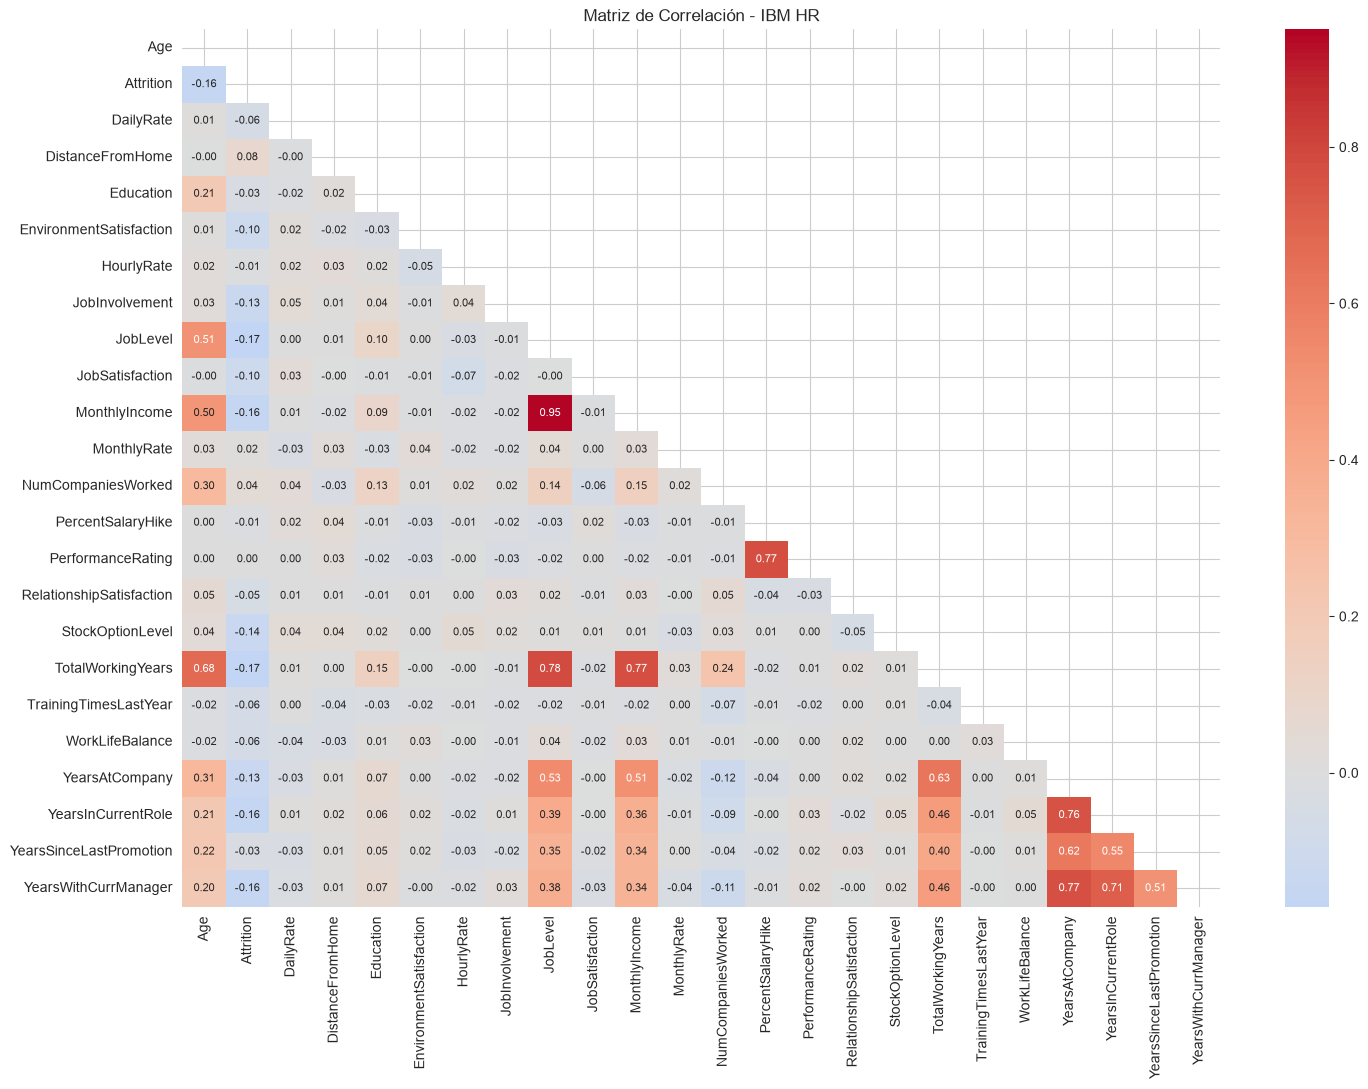

In [19]:
# --- Heatmap de correlaciones ---

# Seleccionamos solo variables numéricas
numericas = ibm_clean.select_dtypes(include=[np.number])

# Calcular correlaciones
corr_matrix = numericas.corr()

# Heatmap
## fig, ax = plt.subplots(figsize=(16, 12))
fig, ax = plt.subplots(figsize=(15, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Solo triangulo inferior
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax,
            annot_kws={'size': 8})
         ## annot_kws={'size': 7})
plt.title('Matriz de Correlación - IBM HR')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

Hallazgo: Podemos ver que hay 7 pares de variables con alta correlación (>0.7) que hay que tratar en la parte de modelado, también se pudieron validar las variables de ruido que vimos anteriormente.
Pero lo más importante, es lo debil que son las correlaciones con attrition, por lo que para obtener el valor predictivo que queremos, tendremos que utilizar múltiples variables.

In [20]:
# --- Identificamos los pares altamente correlacionados ---

# Pares con correlación > 0.7 (excluyendo la diagonal)
threshold = 0.7
high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr.append({
                'Variable_1': corr_matrix.columns[i],
                'Variable_2': corr_matrix.columns[j],
                'Correlacion': round(corr_matrix.iloc[i, j], 3)
            })

high_corr_df = pd.DataFrame(high_corr).sort_values('Correlacion',
                            ascending=False, key=abs)
print(f'Pares con correlacion > {threshold}:')
print(high_corr_df.to_string(index=False))

Pares con correlacion > 0.7:
        Variable_1           Variable_2  Correlacion
          JobLevel        MonthlyIncome        0.950
          JobLevel    TotalWorkingYears        0.782
 PercentSalaryHike    PerformanceRating        0.774
     MonthlyIncome    TotalWorkingYears        0.773
    YearsAtCompany YearsWithCurrManager        0.769
    YearsAtCompany   YearsInCurrentRole        0.759
YearsInCurrentRole YearsWithCurrManager        0.714


Como se pudo ver en el mapa de calor, hay 7 pares con correlación superior a 0.7. Los mas altos son MonthlyIncome-JobLevel (0.95) y las variables temporales entre si (YearsAtCompany, YearsInCurrentRole, YearsWithCurrManager). Tiene sentido: mayor nivel = mayor salario, y un empleado con muchos años en la empresa suele tener muchos años en su rol y con su manager. 
En la fase de modelado habrá que decidir si eliminar alguna de estas variables para evitar que aporten información redundante al modelo.

In [23]:
# --- Correlación point-biserial con el target ---
from scipy.stats import pointbiserialr

# Calcular correlación de cada variable numérica con Attrition
pb_results = []
for col in numericas.columns:
    if col != 'Attrition':
        corr, pvalue = pointbiserialr(ibm_clean['Attrition'], ibm_clean[col])
        pb_results.append({
            'Variable': col,
            'Correlacion': round(corr, 3),
         ## 'P_value': round(pvalue, 3),
            'P_value': round(pvalue, 6),
         ## 'P_value': round(pvalue, 7),            
            'Significativa': 'Si' if pvalue < 0.05 else 'No'
        })

pb_df = pd.DataFrame(pb_results).sort_values('Correlacion', key=abs, ascending=False)
print('=== CORRELACION POINT-BISERIAL CON ATTRITION ===')
print(pb_df.to_string(index=False))

=== CORRELACION POINT-BISERIAL CON ATTRITION ===
                Variable  Correlacion  P_value Significativa
       TotalWorkingYears       -0.171 0.000000            Si
                JobLevel       -0.169 0.000000            Si
      YearsInCurrentRole       -0.161 0.000000            Si
           MonthlyIncome       -0.160 0.000000            Si
                     Age       -0.159 0.000000            Si
    YearsWithCurrManager       -0.156 0.000000            Si
        StockOptionLevel       -0.137 0.000000            Si
          YearsAtCompany       -0.134 0.000000            Si
          JobInvolvement       -0.130 0.000001            Si
 EnvironmentSatisfaction       -0.103 0.000072            Si
         JobSatisfaction       -0.103 0.000070            Si
        DistanceFromHome        0.078 0.002793            Si
         WorkLifeBalance       -0.064 0.014211            Si
   TrainingTimesLastYear       -0.059 0.022578            Si
               DailyRate       -0.05

In [30]:
# --- Test chi-square para categoricas ---
from scipy.stats import chi2_contingency

# Variables categoricas
cats = ibm_clean.select_dtypes(include=['str']).columns.tolist()

chi2_results = []
for col in cats:
    tabla = pd.crosstab(ibm_clean[col], ibm_clean['Attrition'])
    chi2, pvalue, dof, expected = chi2_contingency(tabla)
    chi2_results.append({
        'Variable': col,
        'Chi2': round(chi2, 2),
        'P_value': round(pvalue, 6),
        'Grados_libertad': dof,
        'Significativa': 'Si' if pvalue < 0.05 else 'No'
    })

chi2_df = pd.DataFrame(chi2_results).sort_values('Chi2', ascending=False)
print('=== TEST CHI-SQUARE: CATEGORICAS VS ATTRITION ===')
print(chi2_df.to_string(index=False))

=== TEST CHI-SQUARE: CATEGORICAS VS ATTRITION ===
      Variable  Chi2  P_value  Grados_libertad Significativa
      OverTime 87.56 0.000000                1            Si
       JobRole 86.19 0.000000                8            Si
 MaritalStatus 46.16 0.000000                2            Si
BusinessTravel 24.18 0.000006                2            Si
EducationField 16.02 0.006774                5            Si
    Department 10.80 0.004526                2            Si
        Gender  1.12 0.290572                1            No


In [ ]:
Podemos ver que todas las variables categoricas son significativas (p-value < 0.05) excepto Gender. Las mas fuertes son OverTime (Chi2=87.56) y JobRole (86.19), luego le siguen MaritalStatus 
(46.16) y BusinessTravel (24.18). La parte de que Gender no sea significativa, indica que en este dataset el género no influye en la rotación. Esto se podrá validar realmente en la fase de modelado.

In [31]:
# --- Resumen de significancia completa ---

print('=== RESUMEN DE SIGNIFICANCIA ESTADISTICA ===')
print('\n--- Variables numericas (point-biserial) ---')
sig_num = pb_df[pb_df['Significativa'] == 'Si'].sort_values('Correlacion', key=abs, ascending=False)
print(f'Significativas: {len(sig_num)} de {len(pb_df)}')
print(sig_num[['Variable', 'Correlacion', 'P_value']].to_string(index=False))

print('\n--- Variables categoricas (chi-square) ---')
sig_cat = chi2_df[chi2_df['Significativa'] == 'Si']
print(f'Significativas: {len(sig_cat)} de {len(chi2_df)}')
print(sig_cat[['Variable', 'Chi2', 'P_value']].to_string(index=False))

# Exportar tabla completa
os.makedirs('../reports/tables', exist_ok=True)
pb_df.to_csv('../reports/tables/significancia_numericas.csv', index=False)
chi2_df.to_csv('../reports/tables/significancia_categoricas.csv', index=False)
print('\nTablas exportadas a reports/tables/')

=== RESUMEN DE SIGNIFICANCIA ESTADISTICA ===

--- Variables numericas (point-biserial) ---
Significativas: 15 de 23
               Variable  Correlacion  P_value
      TotalWorkingYears       -0.171 0.000000
               JobLevel       -0.169 0.000000
     YearsInCurrentRole       -0.161 0.000000
          MonthlyIncome       -0.160 0.000000
                    Age       -0.159 0.000000
   YearsWithCurrManager       -0.156 0.000000
       StockOptionLevel       -0.137 0.000000
         YearsAtCompany       -0.134 0.000000
         JobInvolvement       -0.130 0.000001
EnvironmentSatisfaction       -0.103 0.000072
        JobSatisfaction       -0.103 0.000070
       DistanceFromHome        0.078 0.002793
        WorkLifeBalance       -0.064 0.014211
  TrainingTimesLastYear       -0.059 0.022578
              DailyRate       -0.057 0.029858

--- Variables categoricas (chi-square) ---
Significativas: 6 de 7
      Variable  Chi2  P_value
      OverTime 87.56 0.000000
       JobRole 86.19 

## Paso 4: Importancia de las variables (preliminar)
## Entrenamos un Random Forest rápido (sin tunear) para obtener un ranking de importancia. Lo hacemos de modo exploratorio.

In [34]:
# --- Encoding para el Random Forest exploratorio ---
from sklearn.ensemble import RandomForestClassifier

# One-hot encoding de categoricas
ibm_encoded = pd.get_dummies(ibm_clean, drop_first=True)

# Separar features y target
X = ibm_encoded.drop(columns=['Attrition'])
y = ibm_encoded['Attrition']

print(f'Features: {X.shape[1]} columnas')
print(f'Target: {y.value_counts().to_dict()}')

Features: 44 columnas
Target: {0: 1233, 1: 237}


In [38]:
# --- Random Forest exploratorio ---

# Entrenar con parámetros por defecto
rf = RandomForestClassifier(n_estimators=100, random_state=42,
                           class_weight='balanced')
rf.fit(X, y)

# Extraer feature importances
importances = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)

# Mostrar top 15
print('=== TOP 15 VARIABLES POR IMPORTANCIA (Random Forest) ===')
print(importances.head(15).to_string(index=False))

=== TOP 15 VARIABLES POR IMPORTANCIA (Random Forest) ===
            Variable  Importancia
       MonthlyIncome     0.071906
        OverTime_Yes     0.061375
                 Age     0.061045
           DailyRate     0.049441
      YearsAtCompany     0.046750
   TotalWorkingYears     0.046172
         MonthlyRate     0.045295
          HourlyRate     0.042985
    DistanceFromHome     0.040328
YearsWithCurrManager     0.035489
   PercentSalaryHike     0.035087
    StockOptionLevel     0.035077
  NumCompaniesWorked     0.032542
  YearsInCurrentRole     0.030285
     JobSatisfaction     0.030183


In [37]:
print(len(importances))

44


Utilizamos un top 15, debido a que el dataset tenía 40 variables despuées del encoding.

C:\Users\mario\AppData\Local\Temp\ipykernel_27016\361329602.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top15, x='Importancia', y='Variable',


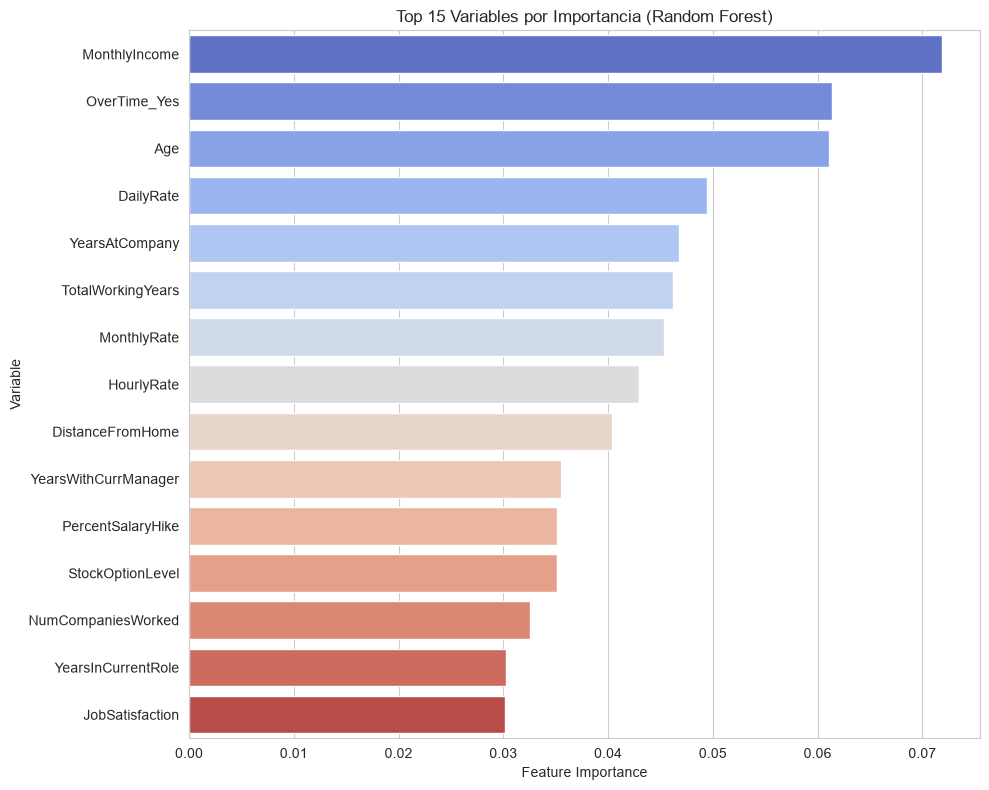

In [41]:
# --- Gráfica de importancia de variables ---

top15 = importances.head(15)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=top15, x='Importancia', y='Variable',
            palette='coolwarm', ax=ax)
ax.set_title('Top 15 Variables por Importancia (Random Forest)', fontsize=12)
ax.set_xlabel('Feature Importance')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance_rf.png',
            dpi=150, bbox_inches='tight')
plt.show()

Vemos que las 3 mas importantes son MonthlyIncome, OverTime y Age. Cuadra con lo que se vio en las correlaciones y los gráficos. DailyRate y MonthlyRate se ven aquí pero no 
salió en las correlaciones, puede ser porque el RF detecta relaciones que el modelo Pearson no. Lo veremos en el modelado.

In [42]:
# --- Compración del RF vs correlaciones ---

# Top 10 del RF
top10_rf = importances.head(10)['Variable'].tolist()

# Top 10 por correlación point-biserial
top10_corr = pb_df.head(10)['Variable'].tolist()

print('=== COMPARATIVA ===')
print(f'\nTop 10 Random Forest: {top10_rf}')
print(f'Top 10 Correlacion:   {top10_corr}')

# Variables en común
comunes = set(top10_rf) & set(top10_corr)
print(f'\nVariables en ambos top 10: {comunes}')
print(f'Coincidencia: {len(comunes)}/10')

=== COMPARATIVA ===

Top 10 Random Forest: ['MonthlyIncome', 'OverTime_Yes', 'Age', 'DailyRate', 'YearsAtCompany', 'TotalWorkingYears', 'MonthlyRate', 'HourlyRate', 'DistanceFromHome', 'YearsWithCurrManager']
Top 10 Correlacion:   ['TotalWorkingYears', 'JobLevel', 'YearsInCurrentRole', 'MonthlyIncome', 'Age', 'YearsWithCurrManager', 'StockOptionLevel', 'YearsAtCompany', 'JobInvolvement', 'EnvironmentSatisfaction']

Variables en ambos top 10: {'TotalWorkingYears', 'MonthlyIncome', 'YearsAtCompany', 'YearsWithCurrManager', 'Age'}
Coincidencia: 5/10


Si hay coincidencia en varias variables es algo bueno, porque significa que esos predictores son consistentes sin importar el método. Las diferencias son normales porque el RF detecta cosas que la correlación lineal no.

## Resumen del EDA:
## Principales hallazgos del análisis exploratorio.

In [43]:
# --- Resumen final ---

print('=' * 60)
print('RESUMEN DEL ANÁLISIS EXPLORATORIO DE DATOS')
print('=' * 60)
print(f'\nDataset: IBM HR Analytics')
print(f'Filas: {ibm_clean.shape[0]} | Columnas: {ibm_clean.shape[1]}')
print(f'Target: Attrition ({ibm_clean["Attrition"].mean():.1%})')
print(f'\nVariables eliminadas: {cols_eliminar}')
print(f'Nulos encontrados: 0')
print(f'Outliers: detectados pero mantenidos (decision justificada)')
print(f'\nVariables numericas significativas: {len(sig_num)}')
print(f'Variables categoricas significativas: {len(sig_cat)}')
print(f'\nTop 5 predictores (RF): {importances.head(5)["Variable"].tolist()}')
print(f'\nArchivos generados:')
print(f'  - data/processed/ibm_hr_clean.csv')
print(f'  - reports/figures/ ({len(os.listdir("../reports/figures"))} graficas)')
print(f'  - reports/tables/ (tablas de significancia)')

RESUMEN DEL ANÁLISIS EXPLORATORIO DE DATOS

Dataset: IBM HR Analytics
Filas: 1470 | Columnas: 31
Target: Attrition (16.1%)

Variables eliminadas: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
Nulos encontrados: 0
Outliers: detectados pero mantenidos (decision justificada)

Variables numericas significativas: 15
Variables categoricas significativas: 6

Top 5 predictores (RF): ['MonthlyIncome', 'OverTime_Yes', 'Age', 'DailyRate', 'YearsAtCompany']

Archivos generados:
  - data/processed/ibm_hr_clean.csv
  - reports/figures/ (17 graficas)
  - reports/tables/ (tablas de significancia)
